# read a market basket database from the csv file provided and generate a dataframe basket of boolean values with one row per transaction and one column per distinct item of the database; the dataframe values must be True if a distinct item is contained in the transaction

In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder

# Variables
file_name= 'mba.csv'
separator = ','
random_state = 42

# Directives
%matplotlib inline
np.random.seed(random_state)
basket = pd.read_csv(file_name, delimiter = separator)
basket.head()

,Item(s),Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,...,Item 23,Item 24,Item 25,Item 26,Item 27,Item 28,Item 29,Item 30,Item 31,Item 32
0,4,citrus fruit,semi-finished bread,margarine,ready soups,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# Open the file
file = open(file_name, mode = 'r')

# The transactions are separated by a ','
# We must also strip the '\n' at the end of the transaction
transactions = [line.strip('\n').split(separator) for line in file.readlines()]

# The first line contains field names that are not relevant, so let's skip it
transactions = transactions[1:]

# The first item in every transaction is a number of the items in the transaction
# we want to use it to slice the list, removing all the empty strings and the 
# number itself
for i in range(len(transactions)):

        # The end index is the number of items in the transaction
        # plus one, because we have the number itself in the slot 0
        end_index = int(transactions[i][0]) + 1
        transactions[i] = transactions[i][1:end_index]

# We now have a list of transactions with only the items in them, we can now
# use TransactionEncoder to obtain an encoded version in boolean form
encoder = TransactionEncoder()
encoded_transactions = encoder.fit_transform(transactions)

# We can now put the encoded transactions in a dataframe
basket = pd.DataFrame(encoded_transactions)
basket.shape[0]

9835

# ignore the transactions containing a single item

In [3]:
# delete row containing less of n_items items
n_items = 2
single_item_transactions = []
# Iterate on all transactions
for index, transaction in basket.iterrows():
    # If there is just one "True" value
    count = 0
    for item in transaction:
        if item == True :
            count = count + 1
    if count <= n_items:
        # Save the index of the transaction
        single_item_transactions.append(index)
# We can now drop those transactions from the dataframe
basket.drop(index = single_item_transactions, axis = 0, inplace = True)
basket.shape[0]

6033

# the column names of the output dataframe are the distinct items

In [6]:
basket.columns= encoder.columns_

In [8]:
basket.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
5,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False


# show the number of transactions and of distinct items

In [13]:
print(f"there are { basket.shape[0] } transaction with a total of {basket.shape[1]} different items")

there are 6033 transaction with a total of 169 different items


# find a value of min_support such that the apriori algorithm generates at least 8 frequent itemsets with at least 2 items

In [17]:
min_itemsets = 8
min_item_in_itemset = 2
# "Reasonable" range
support_range = np.arange(0.1, 0.01, -0.01)

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
min_support = 0
for s_value in support_range:
    print(f"Trying support value {s_value:.2f}")
    frequent_itemsets = apriori(basket, min_support = s_value, use_colnames = True)
    # Calculate the number of itemsets that contain at least `min_item_in_itemset` items
    # frequent_itemsets must contains al least min_itemsets itemsset , and every item set must contains al least min_item_in_itemset item
    itemsets_above_threshold = sum([len(itemset) >= min_item_in_itemset for itemset in frequent_itemsets.itemsets])
    if itemsets_above_threshold >= min_itemsets:
        min_support = s_value
        break
if min_support == 0:
    print("No itemset found! Try again with a bigger range!")
else:
    print(f"I've selected min_support = {min_support:.2f}, which produced , {len(frequent_itemsets)} itemsets, {itemsets_above_threshold} of which had more than {min_item_in_itemset} items")

Trying support value 0.10
Trying support value 0.09
Trying support value 0.08
Trying support value 0.07
Trying support value 0.06
I've selected min_support = 0.06, which produced , 42 itemsets, 9 of which had more than 2 items


# find the minimum metric threshold such that at least 10 association rules are extracted from the frequent itemsets found

In [19]:

metric_threshold_range = np.arange(20, 0.01, -0.01)
min_association_rule = 10
min_metric_threshold = 0
association_rule_found = 0
current_metric = "confidence"

for metric_value in metric_threshold_range:

    rules = association_rules(frequent_itemsets, metric=current_metric, min_threshold=metric_value)
    if rules.shape[0] >= min_association_rule:
        association_rule_found = rules.shape[0]
        min_metric_threshold = metric_value
        break

if association_rule_found == 0:
    print("No association rule! Try again with a bigger range!")
else:
    print(f"I've selected metric {current_metric}  with metric_value = {metric_value:.2f}, which produced , {association_rule_found} association_rules")

I've selected metric confidence  with metric_value = 0.28, which produced , 10 association_rules


# print the first 10 rules sorted by confidence

In [25]:
sorted_rules=rules.sort_values(by=['confidence'],ascending=False).reset_index(drop=True)
sorted_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(root vegetables),(whole milk),0.166750,0.362506,0.079231,0.475149,1.310734,1.0,0.018783,1.214619,0.284511,0.176059,0.176696,0.346857
1,(root vegetables),(other vegetables),0.166750,0.286425,0.076247,0.457256,1.596428,1.0,0.028486,1.314756,0.448367,0.202287,0.239403,0.361730
2,(yogurt),(whole milk),0.203879,0.362506,0.090005,0.441463,1.217809,1.0,0.016098,1.141364,0.224656,0.188935,0.123856,0.344874
3,(tropical fruit),(whole milk),0.156970,0.362506,0.067628,0.430834,1.188488,1.0,0.010725,1.120049,0.188125,0.149670,0.107182,0.308696
4,(other vegetables),(whole milk),0.286425,0.362506,0.121001,0.422454,1.165370,1.0,0.017170,1.103797,0.198862,0.229199,0.094036,0.378122
5,(rolls/buns),(whole milk),0.243163,0.362506,0.090171,0.370825,1.022947,1.0,0.002023,1.013221,0.029640,0.174920,0.013049,0.309784
6,(yogurt),(other vegetables),0.203879,0.286425,0.070114,0.343902,1.200673,1.0,0.011718,1.087606,0.209935,0.166864,0.080549,0.294347
7,(whole milk),(other vegetables),0.362506,0.286425,0.121001,0.333791,1.165370,1.0,0.017170,1.071098,0.222595,0.229199,0.066378,0.378122
8,(soda),(whole milk),0.222112,0.362506,0.064313,0.289552,0.798751,1.0,-0.016204,0.897313,-0.244653,0.123606,-0.114439,0.233482
9,(rolls/buns),(other vegetables),0.243163,0.286425,0.068291,0.280845,0.980521,1.0,-0.001357,0.992242,-0.025578,0.148042,-0.007819,0.259636


#  plot confidence and support for all the sorted rules found

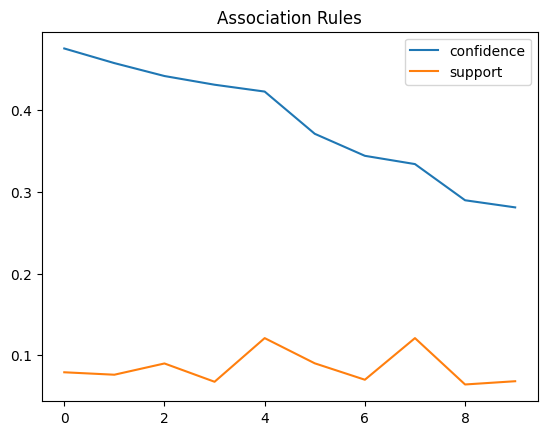

In [28]:
sorted_rules[['confidence','support']].plot(title='Association Rules');

# scatter plot the rules by confidence and support, labelling the points with the index value of the corresponding rule

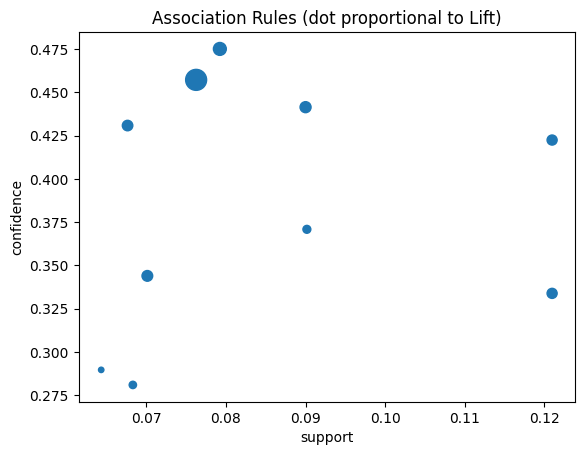

In [31]:
size_point = 30
# The size of each point
s = [size_point**n for n in rules.lift]

rules.plot.scatter(x='support',
                   y='confidence',
                   title='Association Rules (dot proportional to Lift)',
                   s=s);